In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Task 1

In [2]:
# load dataset
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
# Rows -> no. of records
# Columns -> no. of features
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1470
Columns : 35


In [4]:
df['Attrition'].unique()

# The Attrition column is the target variable.

# Yes → Employee left the company.
# No → Employee stayed.

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [5]:
# no. of employees who stayed and left the company
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [6]:
# Attrition Rate
attrition_rate = (df["Attrition"] == "Yes").mean() * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [7]:
# numeric_cols -> number of numeric cols
# categorical_cols -> number of categorical cols

numeric_cols=df.select_dtypes(np.number).columns
categorical_cols=df.select_dtypes(exclude=np.number).columns
print("Numeric Columns :", len(numeric_cols))
print("Categorical Columns :", len(categorical_cols))


Numeric Columns : 26
Categorical Columns : 9


## Observation
### The dataset is imbalanced because only 237 out of 1470 employees (16.12%) left the company, while 1233 employees (83.88%) stayed.

In [8]:
# Check for missing values
df.isnull().sum()

# No missing values found

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
# Drop irrelevant columns

columns_to_drop = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop)
# remaining columns
df.shape[1]

31

In [10]:
# Convert target variable

df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

# Yes/No converted in to 1/0
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [11]:
df['Attrition'].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [12]:
# categorical cols 
categorical_cols=df.select_dtypes(exclude=np.number).columns
categorical_cols

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')

In [13]:
# one hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df_encoded.shape)

(1470, 45)


In [14]:
df_encoded.columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Res

In [15]:
# Separate Features and Target
X = df_encoded.drop("Attrition", axis=1)

y = df_encoded["Attrition"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 44)
Target Shape: (1470,)


In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
# Scale numeric features using StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(1470, 44)


In [18]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


## Task 3

In [19]:
df['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [20]:
# Attrition Rate by Department
department_attrition = (df.groupby("Department")["Attrition"].apply(lambda x: (x == 1).mean() * 100).sort_values(ascending=False))

print(department_attrition)
# Sales department has the highest attrition rate

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


In [21]:
# Attrition Rate by Job Role
jobrole_attrition=(df.groupby('JobRole')['Attrition'].apply(lambda x : (x==1).mean()*100).sort_values(ascending=False))
jobrole_attrition

# Sales Representatives have the highest attrition rate (39.76%), indicating this role experiences the greatest employee turnover.

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

In [22]:
# Attrition vs Monthly Income
print(df.groupby("Attrition")["MonthlyIncome"].mean())
# Employees who left the company earned, on average, Rs. 4,787 per month compared to Rs. 6,833 for employees who stayed.
# This suggests that lower-paid employees were more likely to leave.

Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64


In [23]:
# Attrition vs Work-Life Balance
worklife_attrition = (df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x == 1).mean()*100))

print(worklife_attrition)
# Employees with the lowest work-life balance rating (1) have the highest attrition rate (31.25%).
# Better work-life balance ratings are generally associated with lower employee turnover.

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


In [24]:
# Attrition vs Years at Company
print(df[df["Attrition"]==1]["YearsAtCompany"].value_counts().sort_values(ascending=False))
# The highest attrition occurs during the first year of employment.


YearsAtCompany
1     59
2     27
5     21
3     20
4     19
10    18
0     16
7     11
6      9
8      9
9      8
14     2
13     2
11     2
22     1
40     1
31     1
16     1
32     1
17     1
20     1
18     1
21     1
24     1
19     1
15     1
33     1
23     1
Name: count, dtype: int64


## Business Insights <br> 
1. The Sales department experiences the highest employee turnover, with an attrition rate of 20.63%, compared to 13.84% in Research & Development. This suggests that retention initiatives should prioritize the Sales team.<br> 
2. Sales Representatives have the highest attrition rate (39.76%)—nearly two out of every five employees in this role leave the company. This role may require better incentives, onboarding, or career progression opportunities.<br> 
3. Employees who left the company earned an average monthly income of ₹4,787, whereas those who stayed earned about ₹6,833. This indicates that lower compensation may be associated with higher employee turnover.<br> 
4. Employees reporting the poorest work-life balance (rating = 1) have an attrition rate of 31.25%, which is much higher than employees with better work-life balance ratings. Improving work-life balance could help reduce attrition.<br> 
5. The first year of employment is the most critical retention period, with 59 employees leaving after just one year. Strengthening onboarding, mentoring, and early engagement programs could reduce early-stage attrition.

## Task 4

In [25]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [26]:
# Split Dataset (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (1176, 44)
Testing Samples : (294, 44)


In [27]:
# logistic Regression Model
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [28]:
# Random Forest Classifier Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
# Gradient Boost model
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [30]:
# Logistic Regression
lr_pred = log_model.predict(X_test)
lr_prob = log_model.predict_proba(X_test)[:, 1]

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Gradient Boosting
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

In [31]:
# Accuracy of models
from sklearn.metrics import accuracy_score
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_accuracy)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)
gb_accuracy = accuracy_score(y_test, gb_pred)
print("Gradient Boosting Accuracy:", gb_accuracy)

Logistic Regression Accuracy: 0.7482993197278912
Random Forest Accuracy: 0.8435374149659864
Gradient Boosting Accuracy: 0.8503401360544217


In [32]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

print(results)

                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression   0.341176  0.617021  0.439394  0.798605
1        Random Forest   0.571429  0.085106  0.148148  0.771643
2    Gradient Boosting   0.588235  0.212766  0.312500  0.794125


## Task 5

In [33]:
# Logistic Regression
print("Logistic Regression")
print(classification_report(y_test, lr_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294



In [34]:
# Random Forest
print("Random Forest")
print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294



In [35]:
# Gradient Boosting
print("Gradient Boosting")
print(classification_report(y_test, gb_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [36]:
# ROC-AUC Score

print("Logistic Regression ROC-AUC :", roc_auc_score(y_test, lr_prob))

print("Random Forest ROC-AUC :", roc_auc_score(y_test, rf_prob))

print("Gradient Boosting ROC-AUC :", roc_auc_score(y_test, gb_prob))

Logistic Regression ROC-AUC : 0.798604530967353
Random Forest ROC-AUC : 0.7716426910155914
Gradient Boosting ROC-AUC : 0.7941252476526832


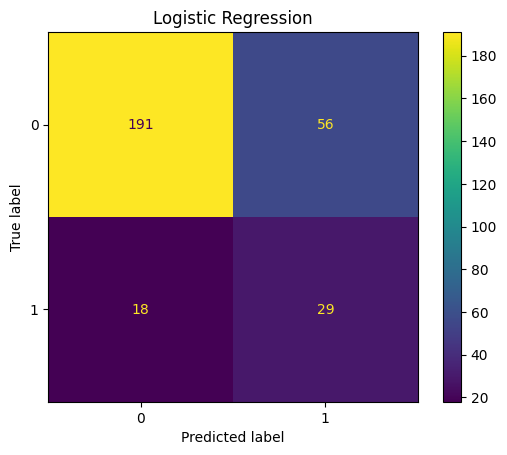

In [37]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Logistic Regression")
plt.show()

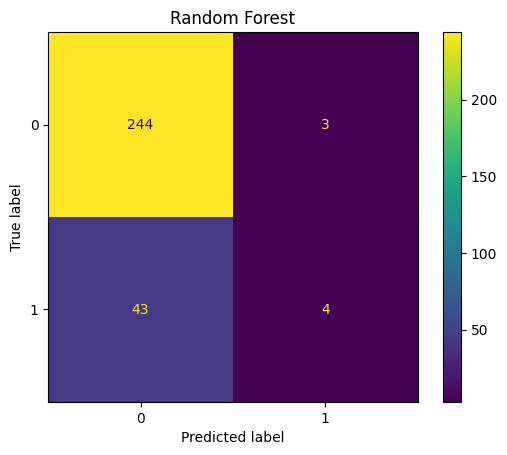

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest")
plt.show()

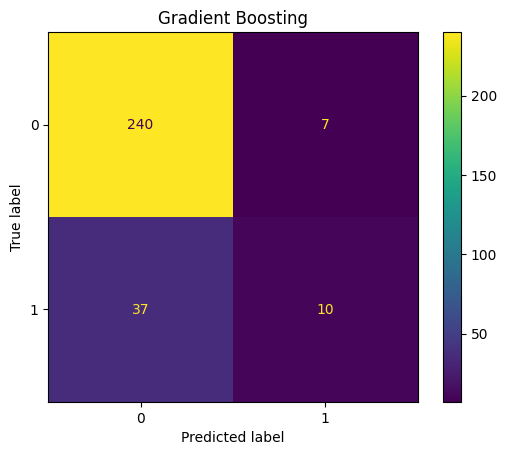

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test, gb_pred)
plt.title("Gradient Boosting")
plt.show()

### Logistic Regression performed the best among the three models.
1. It achieved the highest ROC-AUC score (0.7986), indicating the best ability to distinguish between employees who are likely to leave and those who are likely to stay.
2. It also achieved the highest Recall (0.6170), correctly identifying about 62% of employees who left.
3. The model obtained the highest F1-Score (0.4394), providing the best balance between Precision and Recall.

In [40]:
# Feature Importance for Logistic Regression

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

# Take absolute value for ranking
importance["Importance"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                             Feature  Coefficient  Importance
34     JobRole_Laboratory Technician     0.797874    0.797874
43                      OverTime_Yes     0.766412    0.766412
23  BusinessTravel_Travel_Frequently     0.719335    0.719335
7                           JobLevel     0.659189    0.659189
16                 TotalWorkingYears    -0.656931    0.656931
40      JobRole_Sales Representative     0.552515    0.552515
24      BusinessTravel_Travel_Rarely     0.511649    0.511649
27      EducationField_Life Sciences    -0.506505    0.506505
21           YearsSinceLastPromotion     0.500389    0.500389
26                  Department_Sales     0.481690    0.481690


## Task 7

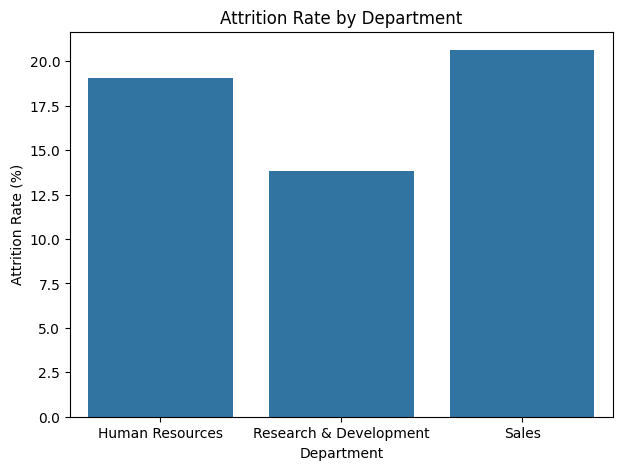

In [41]:
# Chart 1: Attrition Rate by Department

department_attrition = (
    df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == 1).mean() * 100)
    .reset_index(name="Attrition Rate")
)

plt.figure(figsize=(7,5))
sns.barplot(data=department_attrition, x="Department", y="Attrition Rate")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.savefig("charts/department_attrition.png")
plt.show()

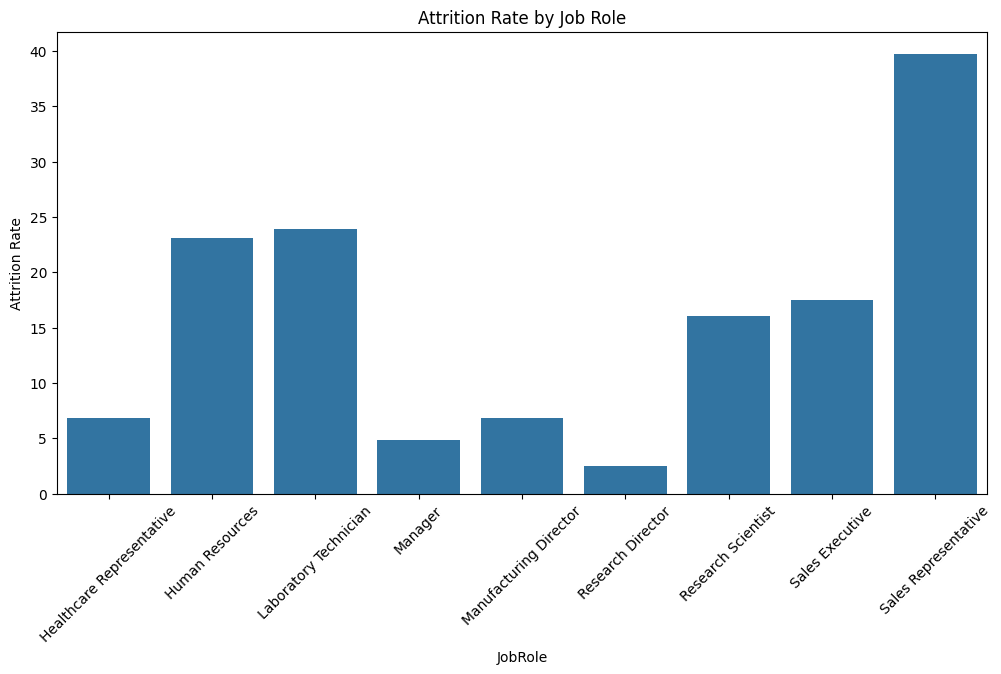

In [42]:
# Chart 1(b): Attrition Rate by Job Role

jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == 1).mean() * 100)
    .reset_index(name="Attrition Rate")
)

plt.figure(figsize=(12,6))
sns.barplot(data=jobrole_attrition,
            x="JobRole",
            y="Attrition Rate")

plt.xticks(rotation=45)
plt.title("Attrition Rate by Job Role")

plt.savefig("charts/jobrole_attrition.png")
plt.show()

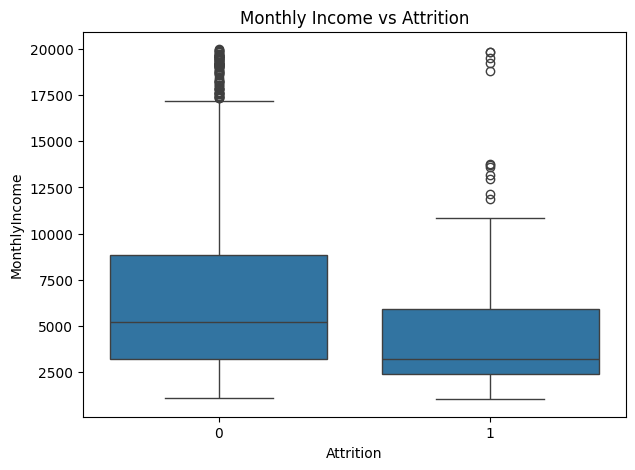

In [43]:
# Chart 2: Monthly Income vs Attrition

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")

plt.savefig("charts/monthly_income_boxplot.png")

plt.show()

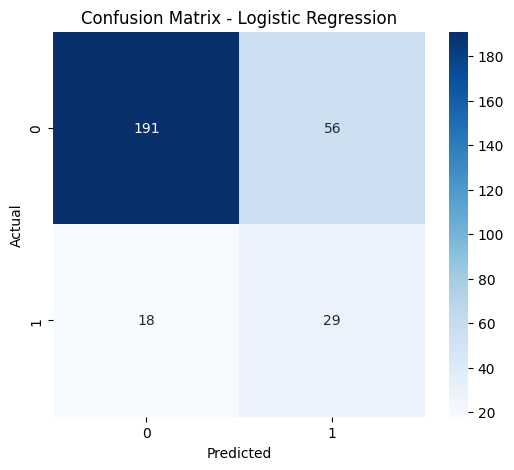

In [44]:
# Chart 3: Confusion Matrix (Best Model)

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("charts/confusion_matrix.png")

plt.show()

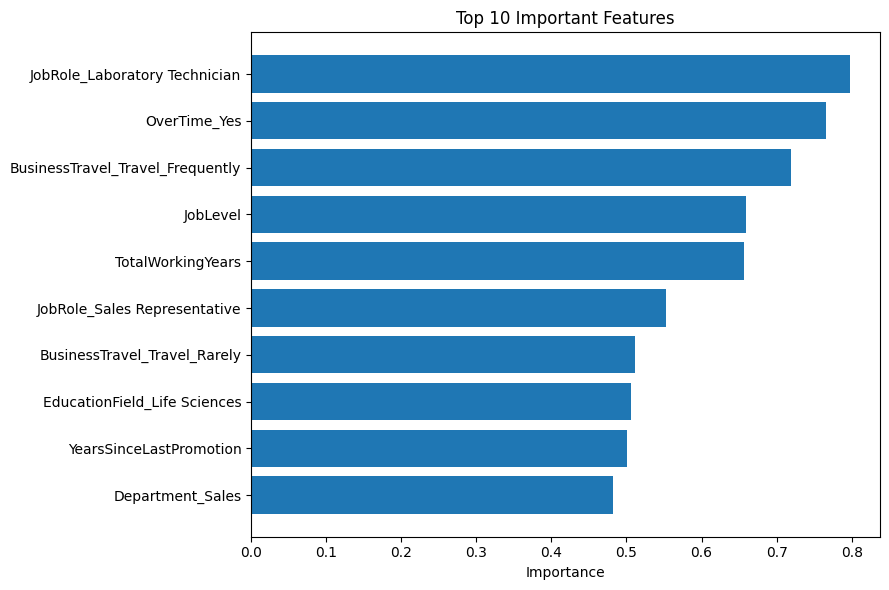

In [45]:
# Chart 4: Top 10 Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

importance["Importance"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = importance.head(10)

plt.figure(figsize=(9,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("charts/top10_features.png")

plt.show()

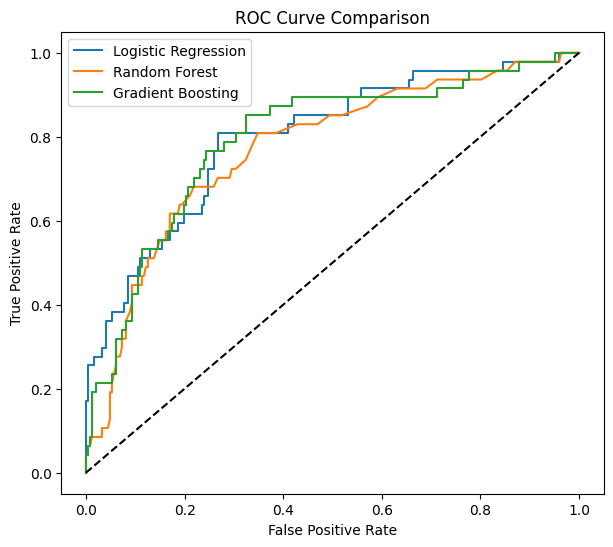

In [46]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(7,6))

plt.plot(lr_fpr, lr_tpr,
         label="Logistic Regression")

plt.plot(rf_fpr, rf_tpr,
         label="Random Forest")

plt.plot(gb_fpr, gb_tpr,
         label="Gradient Boosting")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig("charts/roc_curve.png")

plt.show()

## Task 7

1. Which 3 factors most strongly predict that an employee will leave?

Based on the Logistic Regression feature importance and exploratory data analysis, the three strongest predictors of employee attrition are:

Job Role – Laboratory Technician: Employees in this role have the highest influence on attrition prediction, indicating a higher likelihood of leaving the company.
OverTime: Employees who frequently work overtime are much more likely to leave, suggesting workload and work-life balance significantly impact retention.
Business Travel (Travel Frequently): Employees who travel frequently for work show a higher risk of attrition, likely due to travel-related stress and reduced work-life balance.

2. Which department or job role should HR prioritize for retention efforts?

The Sales department should be the highest priority for HR because it has the highest attrition rate (approximately 20.6%). Among job roles, Sales Representatives have the highest attrition rate (around 40%), followed by Laboratory Technicians (around 24%). HR should focus retention initiatives on employees in these departments and roles.

3. Does salary alone explain attrition, or are there other stronger factors?

No. Although the box plot shows that employees who left generally earned lower monthly incomes than those who stayed, salary is not the only reason for attrition. Factors such as overtime, job role, business travel frequency, job level, and total working years have a strong influence on employee turnover. This indicates that improving the overall employee experience is as important as increasing compensation.

4. Two HR Recommendations

Recommendation 1:
Implement targeted retention programs for Sales Representatives and Laboratory Technicians, including regular career development discussions, mentoring, and performance recognition to improve employee engagement.

Recommendation 2:
Reduce excessive overtime and frequent business travel where possible by balancing workloads, promoting flexible work arrangements, and monitoring employees with high travel requirements to improve work-life balance.

5. Limitation of the Model

The Logistic Regression model provides useful predictions but has some limitations. It relies only on the variables available in the dataset and cannot account for factors such as company culture, leadership quality, employee motivation, personal circumstances, or external job opportunities. Therefore, the model should be used as a decision-support tool rather than the sole basis for HR decisions.